In [ ]:
import os
# Cell 2 — mount Drive and copy .keras model to local VM
from google.colab import drive
drive.mount('/content/drive')

# Edit this to your Drive model path:
DRIVE_MODEL_PATH = "/content/drive/MyDrive/brain_tumor_classifier.keras"  # <- change if needed

# Destination on VM
LOCAL_MODEL_PATH = "/content/brain_tumor_classifier.keras"

# Copy if file exists
if os.path.exists(DRIVE_MODEL_PATH):
    import shutil
    shutil.copy(DRIVE_MODEL_PATH, LOCAL_MODEL_PATH)
    print("Copied model to", LOCAL_MODEL_PATH)
else:
    raise FileNotFoundError(f"Model not found in Drive at: {DRIVE_MODEL_PATH}. Check path and try again.")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Copied model to /content/brain_tumor_classifier.keras


# Load the model

In [ ]:
from tensorflow.keras.models import load_model

# Cell 3 — load the Keras model
print("Loading model from", LOCAL_MODEL_PATH)
model = load_model(LOCAL_MODEL_PATH)
print("Model loaded. Summary:")
model.summary()


Loading model from /content/brain_tumor_classifier.keras
Model loaded. Summary:


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential          │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ sequential[0][0]  │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 224, 224,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati

 Total params: 11,421,464 (43.57 MB)

 Trainable params: 3,603,897 (13.75 MB)

 Non-trainable params: 609,771 (2.33 MB)

 Optimizer params: 7,207,796 (27.50 MB)

# Upload a local image (dummy image) from your computer

In [ ]:
# Cell 4 — upload an image from your local machine (dummy image)
from google.colab import files

print("Use the file picker to upload one image (jpg/png).")
uploaded = files.upload()  # choose file(s)
if len(uploaded) == 0:
    raise SystemExit("No file uploaded.")
# take the first uploaded file
uploaded_filename = list(uploaded.keys())[0]
uploaded_path = os.path.join("/content", uploaded_filename)
print("Uploaded to:", uploaded_path)


Use the file picker to upload one image (jpg/png).


Saving Y86.JPG to Y86.JPG
Uploaded to: /content/Y86.JPG


# Prediction + Grad-CAM localization function

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw
from skimage import measure
import tensorflow as tf
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.efficientnet import preprocess_input


# ---- SETTINGS ----
IMG_SIZE = (224, 224)
DECISION_THRESHOLD = 0.5
HEATMAP_THRESHOLD = 0.4
MIN_AREA = 50


def load_and_preprocess_pil(img_path):
    pil = Image.open(img_path).convert("RGB")
    arr224 = pil.resize(IMG_SIZE)
    arr224 = np.array(arr224).astype(np.uint8)

    inp = np.expand_dims(arr224.copy(), axis=0)
    inp = preprocess_input(inp)

    return pil, arr224, inp


def make_gradcam_heatmap_pil(img_array, model, last_conv_layer_name="top_conv", eps=1e-8):
    grad_model = tf.keras.models.Model(
        [model.inputs],
        [model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, preds = grad_model(img_array)
        loss = preds[:, 0]

    grads = tape.gradient(loss, conv_outputs)
    conv_outputs = conv_outputs[0].numpy()
    grads = grads[0].numpy()
    weights = np.mean(grads, axis=(0, 1))

    heatmap = np.dot(conv_outputs, weights)
    heatmap = np.maximum(heatmap, 0)

    if heatmap.max() != 0:
        heatmap /= heatmap.max()

    return heatmap


def overlay_heatmap_pil(original_pil, heatmap):
    heatmap_img = Image.fromarray(np.uint8(heatmap * 255))
    heatmap_img = heatmap_img.resize(original_pil.size)
    heatmap_img = heatmap_img.convert("RGB")

    # Colorize using matplotlib colormap
    import matplotlib.cm as cm
    colormap = cm.get_cmap("jet")
    colored = colormap(np.array(heatmap_img) / 255.0)[:, :, :3]
    colored = (colored * 255).astype(np.uint8)
    colored_img = Image.fromarray(colored)

    blended = Image.blend(original_pil, colored_img, alpha=0.5)
    return blended


def bbox_from_heatmap_pil(heatmap_resized):
    mask = (heatmap_resized >= HEATMAP_THRESHOLD).astype(np.uint8)
    labels = measure.label(mask, connectivity=2)

    if labels.max() == 0:
        return None, mask

    props = measure.regionprops(labels)
    areas = [p.area for p in props]
    max_idx = np.argmax(areas)

    if areas[max_idx] < MIN_AREA:
        return None, mask

    y_min, x_min, y_max, x_max = props[max_idx].bbox
    return (x_min, y_min, x_max, y_max), mask


def predict_and_localize_no_cv(img_path, model, last_conv="top_conv", display=True):
    original_pil, arr224, inp = load_and_preprocess_pil(img_path)

    prob = float(model.predict(inp)[0][0])
    label = "Tumor" if prob >= DECISION_THRESHOLD else "No Tumor"

    print(f"Prediction: {label} (prob={prob:.4f})")

    if label == "No Tumor":
        plt.imshow(original_pil)
        plt.title(f"No Tumor (prob={prob:.4f})")
        plt.axis("off")
        return

    # Grad-CAM
    heatmap_low = make_gradcam_heatmap_pil(inp, model, last_conv)
    heatmap_resized = np.array(Image.fromarray((heatmap_low * 255).astype(np.uint8)).resize(original_pil.size)) / 255.0

    overlay = overlay_heatmap_pil(original_pil, heatmap_resized)

    bbox, mask = bbox_from_heatmap_pil(heatmap_resized)

    overlay_box = overlay.copy()
    if bbox:
        draw = ImageDraw.Draw(overlay_box)
        x_min, y_min, x_max, y_max = bbox
        draw.rectangle([x_min, y_min, x_max, y_max], outline="yellow", width=3)

    # Display results
    if display:
        plt.figure(figsize=(14, 6))
        plt.subplot(1, 3, 1); plt.imshow(original_pil); plt.title("Original"); plt.axis("off")
        plt.subplot(1, 3, 2); plt.imshow(overlay); plt.title("Grad-CAM Overlay"); plt.axis("off")
        plt.subplot(1, 3, 3); plt.imshow(overlay_box); plt.title(f"Detected Tumor {bbox}"); plt.axis("off")
        plt.show()

    return {"prob": prob, "label": label, "bbox": bbox, "overlay": overlay_box}


# Run the prediction & localization on the uploaded image

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
Prediction: Tumor (prob=0.9757)


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['input_layer']]
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


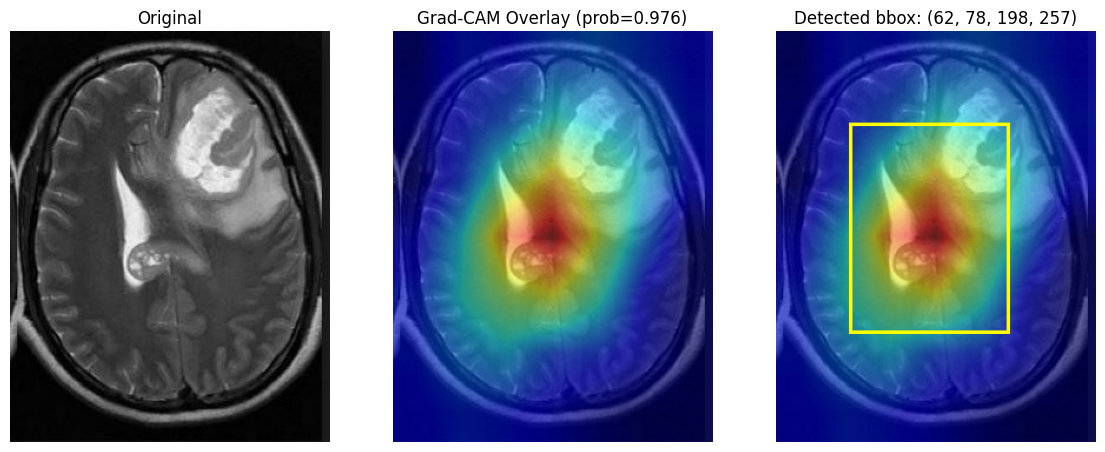

Saved overlay to: /content/overlay_fixed.png
Result: {'label': 'Tumor', 'probability': 0.9756956696510315, 'bbox': (62, 78, 198, 257), 'overlay': <PIL.Image.Image image mode=RGB size=272x350 at 0x799DA01C71A0>, 'heatmap': 'heatmap_array'}


In [ ]:
# Fixed no-OpenCV Grad-CAM + overlay (replacement cell)
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw
from skimage import measure
import tensorflow as tf
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.efficientnet import preprocess_input

# settings
IMG_SIZE = (224,224)
DECISION_THRESHOLD = 0.5
HEATMAP_THRESHOLD = 0.4
MIN_AREA = 50

def load_and_preprocess_pil(img_path):
    original_pil = Image.open(img_path).convert("RGB")
    resized = original_pil.resize(IMG_SIZE)
    arr224 = np.array(resized).astype(np.uint8)
    inp = np.expand_dims(arr224.copy(), axis=0)
    inp = preprocess_input(inp)
    return original_pil, arr224, inp

def make_gradcam_heatmap_pil(img_array, model, last_conv_layer_name="top_conv", eps=1e-8):
    grad_model = tf.keras.models.Model([model.inputs], [model.get_layer(last_conv_layer_name).output, model.output])
    with tf.GradientTape() as tape:
        conv_outputs, preds = grad_model(img_array)
        loss = preds[:, 0]
    grads = tape.gradient(loss, conv_outputs)
    conv_outputs = conv_outputs[0].numpy()   # H x W x C
    grads = grads[0].numpy()                 # H x W x C
    weights = np.mean(grads, axis=(0,1))     # C
    # weighted sum of feature maps
    heatmap = np.tensordot(conv_outputs, weights, axes=([2],[0]))  # H x W
    heatmap = np.maximum(heatmap, 0)
    if heatmap.max() != 0:
        heatmap = heatmap / (heatmap.max() + eps)
    return heatmap

def overlay_heatmap_pil(original_pil, heatmap_2d, alpha=0.5, cmap_name="jet"):
    # heatmap_2d expected 2D float 0..1 with same spatial size as original_pil when resized below
    # Resize heatmap to original size
    heatmap_img = Image.fromarray(np.uint8(heatmap_2d * 255))            # 2D -> grayscale image
    heatmap_resized = heatmap_img.resize(original_pil.size, resample=Image.BILINEAR)
    heatmap_resized_arr = np.array(heatmap_resized) / 255.0              # 2D float 0..1
    # Apply colormap (matplotlib) on 2D heatmap
    cmap = plt.get_cmap(cmap_name)
    colored = cmap(heatmap_resized_arr)[:, :, :3]                        # H x W x 3 float 0..1
    colored_uint8 = (colored * 255).astype(np.uint8)
    colored_img = Image.fromarray(colored_uint8)
    # Blend with original
    blended = Image.blend(original_pil.convert("RGBA"), colored_img.convert("RGBA"), alpha=alpha)
    return blended.convert("RGB"), heatmap_resized_arr

def bbox_from_heatmap_pil(heatmap_resized_arr, threshold=HEATMAP_THRESHOLD, min_area=MIN_AREA):
    mask = (heatmap_resized_arr >= threshold).astype(np.uint8)
    labels = measure.label(mask, connectivity=2)
    if labels.max() == 0:
        return None, mask
    props = measure.regionprops(labels)
    areas = [p.area for p in props]
    max_idx = int(np.argmax(areas))
    if areas[max_idx] < min_area:
        return None, mask
    y_min, x_min, y_max, x_max = props[max_idx].bbox
    return (x_min, y_min, x_max, y_max), mask

def predict_and_localize_no_cv_fixed(img_path, model, last_conv="top_conv", display=True, save_overlay_path=None):
    original_pil, arr224, inp = load_and_preprocess_pil(img_path)
    prob = float(model.predict(inp)[0][0])
    label = "Tumor" if prob >= DECISION_THRESHOLD else "No Tumor"
    print(f"Prediction: {label} (prob={prob:.4f})")
    if label == "No Tumor":
        if display:
            plt.figure(figsize=(6,6)); plt.imshow(original_pil); plt.title(f"No Tumor (prob={prob:.4f})"); plt.axis("off"); plt.show()
        return {"label": label, "probability": prob, "bbox": None, "overlay": None}
    # Grad-CAM heatmap (low-res)
    heatmap_low = make_gradcam_heatmap_pil(inp, model, last_conv)
    # Resize heatmap to original image size and create overlay
    overlay_img, heatmap_resized_arr = overlay_heatmap_pil(original_pil, heatmap_low, alpha=0.5, cmap_name="jet")
    bbox, mask = bbox_from_heatmap_pil(heatmap_resized_arr)
    # draw bbox on overlay copy
    overlay_with_box = overlay_img.copy()
    if bbox is not None:
        draw = ImageDraw.Draw(overlay_with_box)
        x_min, y_min, x_max, y_max = bbox
        draw.rectangle([x_min, y_min, x_max, y_max], outline=(255,255,0), width=3)
    if display:
        plt.figure(figsize=(14,6))
        plt.subplot(1,3,1); plt.imshow(original_pil); plt.title("Original"); plt.axis("off")
        plt.subplot(1,3,2); plt.imshow(overlay_img); plt.title(f"Grad-CAM Overlay (prob={prob:.3f})"); plt.axis("off")
        plt.subplot(1,3,3);
        if bbox is not None:
            plt.imshow(overlay_with_box); plt.title(f"Detected bbox: {bbox}")
        else:
            plt.imshow(overlay_img); plt.title("No region above threshold")
        plt.axis("off")
        plt.show()
    if save_overlay_path:
        overlay_with_box.save(save_overlay_path)
        print("Saved overlay to:", save_overlay_path)
    return {"label": label, "probability": prob, "bbox": bbox, "overlay": overlay_with_box, "heatmap": heatmap_resized_arr}

# Run on the uploaded image (replace uploaded_path with your image path if needed)
res = predict_and_localize_no_cv_fixed(uploaded_path, model, last_conv="top_conv", display=True, save_overlay_path="/content/overlay_fixed.png")
print("Result:", {k: (v if k!="heatmap" else "heatmap_array") for k,v in res.items()})


In [ ]:
# Gradio app: upload image -> predict -> (if Tumor) Grad-CAM overlay + bbox
# Run this cell in Colab or local env.
# If in Colab, set share=True in demo.launch(...) to get a public link.

!pip install -q gradio scikit-image imageio

import gradio as gr
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.efficientnet import preprocess_input
from PIL import Image, ImageDraw
from skimage import measure
import matplotlib.pyplot as plt
import os
import io

# ---------- CONFIG ----------
# If you're using Colab and already copied model into /content, set that path:
LOCAL_MODEL_PATH = "/content/brain_tumor_classifier.keras"  # change if needed

IMG_SIZE = (224,224)
DECISION_THRESHOLD = 0.5
HEATMAP_THRESHOLD = 0.4
MIN_AREA = 50
LAST_CONV_NAME = "top_conv"  # change if your model's last conv layer is different

# ---------- LOAD MODEL ----------
if not os.path.exists(LOCAL_MODEL_PATH):
    raise FileNotFoundError(f"Model file not found at {LOCAL_MODEL_PATH}. Upload or copy it to this path.")

model = load_model(LOCAL_MODEL_PATH)
print("Model loaded.")

# ---------- HELPERS: preprocessing & Grad-CAM (no OpenCV) ----------
def pil_to_arr224(pil_img):
    pil = pil_img.convert("RGB")
    resized = pil.resize(IMG_SIZE)
    arr = np.array(resized).astype(np.uint8)
    return pil, arr

def preprocess_for_model(arr):
    inp = np.expand_dims(arr.copy(), axis=0)
    inp = preprocess_input(inp)
    return inp

def make_gradcam_heatmap_pil(img_tensor, model, last_conv_layer_name=LAST_CONV_NAME, eps=1e-8):
    grad_model = tf.keras.models.Model([model.inputs], [model.get_layer(last_conv_layer_name).output, model.output])
    with tf.GradientTape() as tape:
        conv_outputs, preds = grad_model(img_tensor)
        loss = preds[:, 0]
    grads = tape.gradient(loss, conv_outputs)
    conv_outputs = conv_outputs[0].numpy()   # H x W x C
    grads = grads[0].numpy()                 # H x W x C
    weights = np.mean(grads, axis=(0,1))     # C
    heatmap = np.tensordot(conv_outputs, weights, axes=([2],[0]))  # H x W
    heatmap = np.maximum(heatmap, 0)
    if heatmap.max() != 0:
        heatmap = heatmap / (heatmap.max() + eps)
    return heatmap

def overlay_heatmap_pil(original_pil, heatmap_2d, alpha=0.5, cmap_name="jet"):
    # Create colored heatmap from 2D array
    from matplotlib import cm
    heatmap_img = Image.fromarray(np.uint8(heatmap_2d * 255))
    heatmap_resized = heatmap_img.resize(original_pil.size, resample=Image.BILINEAR)
    heatmap_resized_arr = np.array(heatmap_resized) / 255.0  # H x W floats
    cmap = plt.get_cmap(cmap_name)
    colored = cmap(heatmap_resized_arr)[:, :, :3]           # H x W x 3 (float 0..1)
    colored_uint8 = (colored * 255).astype(np.uint8)
    colored_img = Image.fromarray(colored_uint8)
    blended = Image.blend(original_pil.convert("RGBA"), colored_img.convert("RGBA"), alpha=alpha)
    return blended.convert("RGB"), heatmap_resized_arr

def bbox_from_heatmap_pil(heatmap_resized_arr, threshold=HEATMAP_THRESHOLD, min_area=MIN_AREA):
    mask = (heatmap_resized_arr >= threshold).astype(np.uint8)
    labels = measure.label(mask, connectivity=2)
    if labels.max() == 0:
        return None, mask
    props = measure.regionprops(labels)
    areas = [p.area for p in props]
    max_idx = int(np.argmax(areas))
    if areas[max_idx] < min_area:
        return None, mask
    y_min, x_min, y_max, x_max = props[max_idx].bbox
    return (x_min, y_min, x_max, y_max), mask

# ---------- MAIN predict+localize function used by Gradio ----------
def predict_and_localize_gradio(pil_image):
    """
    Input: PIL image (from Gradio uploader)
    Returns: label_str, probability (float), overlay image (PIL)
    """
    original_pil, arr224 = pil_to_arr224(pil_image)
    inp = preprocess_for_model(arr224)
    prob = float(model.predict(inp)[0][0])
    label = "Tumor" if prob >= DECISION_THRESHOLD else "No Tumor"
    # Default overlay: original image
    overlay_to_return = original_pil.copy()

    if label == "Tumor":
        heatmap_low = make_gradcam_heatmap_pil(inp, model, LAST_CONV_NAME)
        overlay_img, heatmap_resized_arr = overlay_heatmap_pil(original_pil, heatmap_low, alpha=0.5, cmap_name="jet")
        bbox, mask = bbox_from_heatmap_pil(heatmap_resized_arr)
        overlay_box = overlay_img.copy()
        if bbox is not None:
            draw = ImageDraw.Draw(overlay_box)
            x_min, y_min, x_max, y_max = bbox
            draw.rectangle([x_min, y_min, x_max, y_max], outline=(255,255,0), width=3)
        overlay_to_return = overlay_box
    else:
        # Optionally annotate probability on image
        draw = ImageDraw.Draw(overlay_to_return)
        draw.text((10,10), f"No Tumor ({prob:.3f})", fill=(255,0,0))
    label_text = f"{label} (prob={prob:.4f})"
    return label_text, prob, overlay_to_return

# ---------- Build Gradio interface ----------
title = "Brain Tumor Detection + Localization"
description = "Upload an MRI image. The model predicts Tumor/No Tumor. If Tumor, shows Grad-CAM overlay and bounding box."
examples = []  # you can add example images if you want

with gr.Blocks() as demo:
    gr.Markdown(f"## {title}\n\n{description}")
    with gr.Row():
        img_in = gr.Image(type="pil", label="Upload MRI image")
        with gr.Column():
            out_label = gr.Textbox(label="Prediction")
            out_prob  = gr.Number(label="Probability")
            out_img   = gr.Image(type="pil", label="Overlay (if Tumor)")
    btn = gr.Button("Predict & Localize")
    btn.click(fn=predict_and_localize_gradio, inputs=img_in, outputs=[out_label, out_prob, out_img])

# ---------- Launch app ----------
# If in Colab, set share=True to get a public URL.
demo.launch(share=True)


Model loaded.
Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://25e5ebf944e7c45f0c.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
